# YOLO26x Step by Step: Follow One Frame

**Question:** a warm model call is fast. Why can a video pipeline still be slow?

```text
correct model -> deployment engine -> frame boundaries -> resident path
-> parity -> stage A/B -> VLM side path -> production proof
```

Each step answers one question with one artifact. Detailed logs stay in `output/step_by_step/logs/`.

## 1. Lock the experiment

**Question:** are model, GPU, provider, video, and cache fixed?

**Evidence:** verified assets plus three source frames.  
**Next:** establish a familiar PyTorch result.

Environment validation: complete (full log: /workspace/output/step_by_step/logs/environment.log)


**Runtime ready:** `AMD Radeon PRO W7900D` / `gfx1100`; OpenCV HIP devices: `1`; model mapping: `/workspace/models` -> `/workspace/models` (existing model directory).

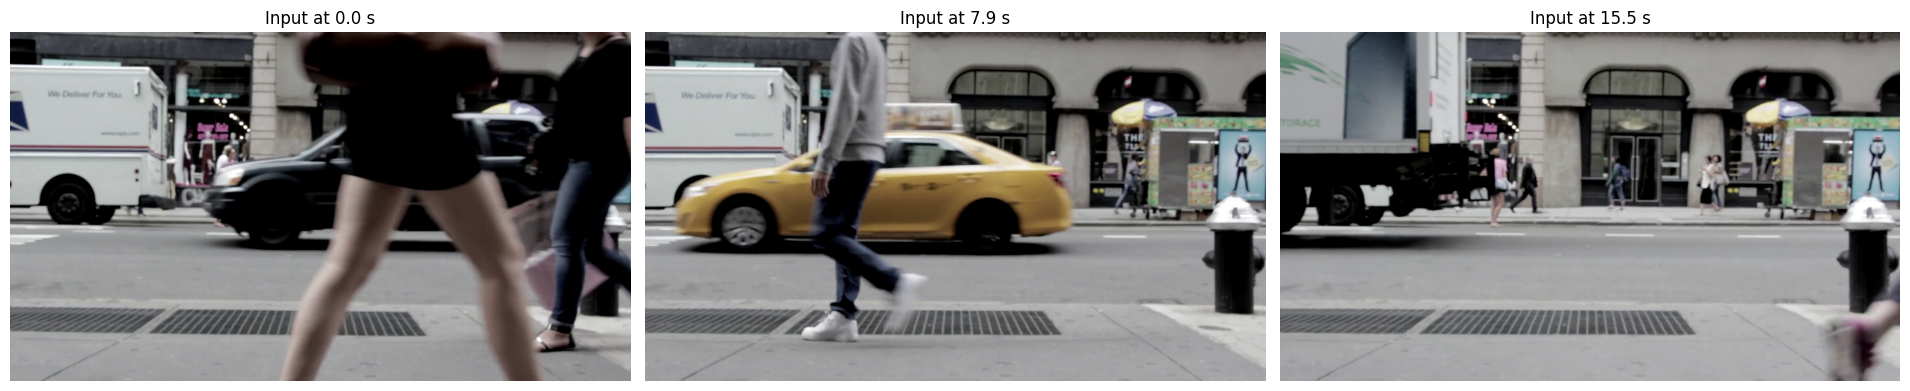

### Verified model and backend assets

- `yolo26x.pt`
- `yolo26x.onnx`
- `Qwen3-VL-8B-Instruct-Q8_0.gguf`
- `mmproj-F16.gguf`
- ORT providers: `MIGraphXExecutionProvider, CPUExecutionProvider`
- MIGraphX cache: `/workspace/models/ort-migraphx-cache`
- Writable output: `/workspace/output/step_by_step`

In [1]:
import importlib
import json
import os
import sys
from pathlib import Path


NOTEBOOK_DIR = Path.cwd().resolve()
BAKED_SEED = Path(os.environ.get(
    "ULTRALYTICS_WORKSHOP_SEED_DIR", "/opt/ultralytics-yolo26/seed"
)).resolve()
BAKED_MODELS = Path(os.environ.get(
    "ULTRALYTICS_BAKED_MODEL_DIR", "/opt/ultralytics-yolo26/models"
)).resolve()


def is_package_root(path: Path) -> bool:
    return (
        (path / "scripts/notebook_env.py").is_file()
        and (path / "src").is_dir()
        and (path / "data").is_dir()
    )


def find_package_root() -> Path:
    candidates = []
    for variable in ("ULTRALYTICS_YOLO26_ROOT", "OPENCV_AMD_END2END_ROOT"):
        if os.environ.get(variable):
            candidates.append(Path(os.environ[variable]).expanduser())
    candidates.extend([NOTEBOOK_DIR, *NOTEBOOK_DIR.parents])
    candidates.extend(Path(value) for value in sys.path if value)
    candidates.append(BAKED_SEED)

    visited = set()
    for origin in candidates:
        try:
            resolved = origin.resolve()
        except (OSError, RuntimeError):
            continue
        for candidate in (resolved, *resolved.parents):
            if candidate in visited:
                continue
            visited.add(candidate)
            if is_package_root(candidate):
                return candidate
    raise FileNotFoundError(
        "Cannot find the ultralytics_yolo26 sources from the current directory "
        f"({NOTEBOOK_DIR}) or immutable seed ({BAKED_SEED})."
    )


def map_baked_models(work_dir: Path, source_dir: Path) -> tuple[Path, str]:
    required = (
        "yolo26x.pt",
        "yolo26x.onnx",
        "Qwen3-VL-8B-Instruct-Q8_0.gguf",
        "mmproj-F16.gguf",
    )
    missing = [name for name in required if not (source_dir / name).is_file()]
    if missing:
        raise FileNotFoundError(
            f"Baked model directory is incomplete: {source_dir}; missing={missing}"
        )

    alias = work_dir / "models"
    if alias.is_symlink():
        if alias.resolve() != source_dir:
            alias.unlink()
            alias.symlink_to(source_dir, target_is_directory=True)
        return alias.resolve(), "symlink"
    if alias.exists():
        if alias.resolve() == source_dir:
            return source_dir, "existing mapping"
        local_missing = [name for name in required if not (alias / name).is_file()]
        if local_missing:
            raise RuntimeError(
                f"Cannot map baked models: {alias} is an existing real path and "
                f"does not contain the release model set (missing={local_missing}). "
                "Remove that mount/directory or set ULTRALYTICS_YOLO26_MODEL_DIR "
                "to a complete model set."
            )
        return alias.resolve(), "existing model directory"

    try:
        alias.symlink_to(source_dir, target_is_directory=True)
        return alias.resolve(), "symlink"
    except OSError as error:
        print(
            f"[bootstrap] Cannot create {alias} -> {source_dir}: {error}. "
            "Using the immutable model directory directly."
        )
        return source_dir, "direct fallback"


ROOT = find_package_root()
MODEL_DIR, MODEL_MAPPING = map_baked_models(NOTEBOOK_DIR, BAKED_MODELS)
OUTPUT_DIR = NOTEBOOK_DIR / "output" / "step_by_step"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

os.environ["ULTRALYTICS_YOLO26_ROOT"] = str(ROOT)
os.environ["ULTRALYTICS_YOLO26_MODEL_DIR"] = str(MODEL_DIR)
os.environ["ULTRALYTICS_YOLO26_OUTPUT_DIR"] = str(OUTPUT_DIR)
os.environ["ULTRALYTICS_YOLO26_PIPELINE_DIR"] = str(
    NOTEBOOK_DIR / "output" / "pipeline"
)
os.environ["ULTRALYTICS_MIGRAPHX_CACHE_ROOT"] = str(
    MODEL_DIR / "ort-migraphx-cache"
)
os.environ.setdefault("HF_ENDPOINT", "https://hf-mirror.com")
for value in (str(ROOT), str(ROOT / "src")):
    if value not in sys.path:
        sys.path.insert(0, value)

from scripts import notebook_env as env
env = importlib.reload(env)
from IPython.display import Markdown, display
from scripts.model_setup import ensure_models, model_status
from scripts import notebook_helpers
notebook_helpers = importlib.reload(notebook_helpers)
from scripts.notebook_helpers import (
    capture_log,
    frame_at,
    show_bgr,
    show_bgr_grid,
    show_video,
    video_info,
)
from scripts.validate_runtime import validate

delivery_mode = (
    "baked/offline verification"
    if os.environ.get("ULTRALYTICS_WORKSHOP_BUNDLE") == "baked"
    else "development fallback download"
)
with capture_log(env.OUTPUT / "logs/environment.log", "Environment validation"):
    models = ensure_models(env.MODELS, progress=True)
    runtime = validate(require_models=True, require_vlm=False)

source_info = video_info(env.SOURCE_VIDEO)
preview_times = [
    0.0,
    source_info["duration_seconds"] / 2,
    max(0.0, source_info["duration_seconds"] - 0.2),
]
source_preview_frames = [frame_at(env.SOURCE_VIDEO, seconds) for seconds in preview_times]
first_frame = source_preview_frames[0]
display(Markdown(
    f"**Runtime ready:** `{runtime['torch_gpu']}` / `{runtime['gpu_arch']}`; "
    f"OpenCV HIP devices: `{runtime['opencv_hip_devices']}`; model mapping: "
    f"`{NOTEBOOK_DIR / 'models'}` -> `{MODEL_DIR}` ({MODEL_MAPPING})."
))
show_bgr_grid(
    source_preview_frames,
    [f"Input at {seconds:.1f} s" for seconds in preview_times],
    columns=3,
)

native_build = ROOT / "native/build"
if native_build.is_dir():
    native_build_text = str(native_build)
    if native_build_text not in sys.path:
        sys.path.insert(0, native_build_text)
    existing_pythonpath = os.environ.get("PYTHONPATH", "")
    pythonpath_entries = existing_pythonpath.split(":") if existing_pythonpath else []
    if native_build_text not in pythonpath_entries:
        os.environ["PYTHONPATH"] = ":".join([native_build_text, *pythonpath_entries])

verified_model_names = [Path(item["path"]).name for item in models if item["ready"]]
display(Markdown(
    "### Verified model and backend assets\n\n"
    + "\n".join(f"- `{name}`" for name in verified_model_names)
    + "\n"
    + f"- ORT providers: `{', '.join(runtime['onnxruntime_providers'])}`\n"
    + f"- MIGraphX cache: `{runtime['migraphx_cache']}`\n"
    + f"- Writable output: `{env.OUTPUT}`"
))

## 2. Establish the model contract

**Question:** what must deployment preserve?

**Evidence:** PyTorch detections and static ONNX: `1x3x640x640 -> 1x300x6`.  
**Next:** separate first-run cost from steady-state cost.

PyTorch inference and ONNX export: complete (full log: /workspace/output/step_by_step/logs/pt_to_onnx.log)


**Conversion result:** `[1, 3, 640, 640]` -> `[1, 300, 6]`; 212.9 MiB; exported in `2.93 s`.

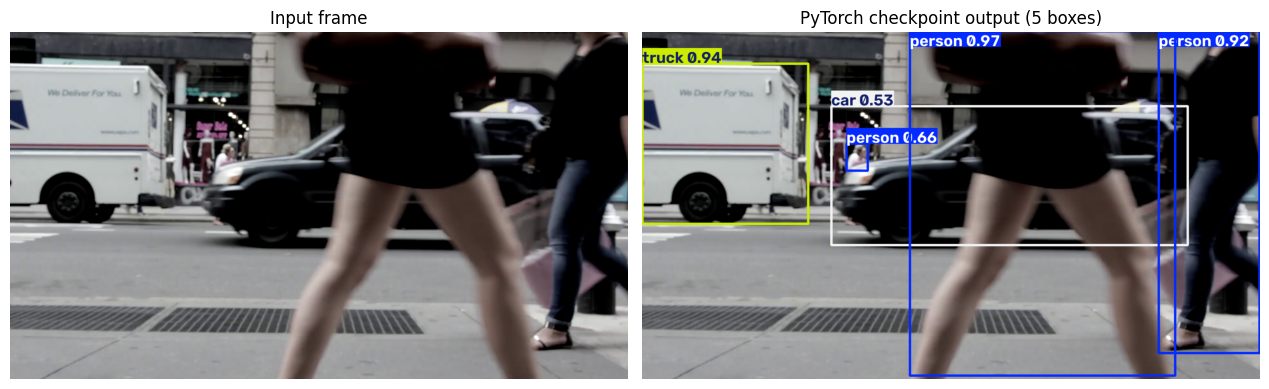

In [2]:
import gc
import hashlib
import shutil
import time

import onnx
import torch
from ultralytics import YOLO

RUN_EXPORT = os.environ.get("RUN_EXPORT", "1") == "1"
export_dir = env.OUTPUT / "export"
export_dir.mkdir(parents=True, exist_ok=True)

with capture_log(env.OUTPUT / "logs/pt_to_onnx.log", "PyTorch inference and ONNX export"):
    pt_model = YOLO(str(env.YOLO_CHECKPOINT))
    pt_result = pt_model.predict(
        first_frame,
        device=0,
        half=True,
        imgsz=640,
        conf=0.5,
        iou=0.45,
        verbose=False,
    )[0]
    if RUN_EXPORT:
        checkpoint_copy = export_dir / env.YOLO_CHECKPOINT.name
        shutil.copy2(env.YOLO_CHECKPOINT, checkpoint_copy)
        export_started = time.perf_counter()
        export_model = YOLO(str(checkpoint_copy))
        workshop_onnx = Path(export_model.export(
            format="onnx",
            imgsz=640,
            batch=1,
            dynamic=False,
            simplify=False,
            device=0,
        )).resolve()
        export_seconds = time.perf_counter() - export_started
        del export_model
    else:
        workshop_onnx = env.YOLO_ONNX
        export_seconds = None

pt_plot = pt_result.plot()
onnx_model = onnx.load(str(workshop_onnx), load_external_data=False)
onnx.checker.check_model(onnx_model)
input_shape = [dim.dim_value for dim in onnx_model.graph.input[0].type.tensor_type.shape.dim]
output_shape = [dim.dim_value for dim in onnx_model.graph.output[0].type.tensor_type.shape.dim]
metadata = {item.key: item.value for item in onnx_model.metadata_props}
onnx_sha256 = hashlib.sha256(workshop_onnx.read_bytes()).hexdigest()
export_record = {
    "checkpoint": str(env.YOLO_CHECKPOINT),
    "onnx": str(workshop_onnx),
    "export_seconds": None if export_seconds is None else round(export_seconds, 3),
    "bytes": workshop_onnx.stat().st_size,
    "sha256": onnx_sha256,
    "input_shape": input_shape,
    "output_shape": output_shape,
    "dynamic": False,
    "task": metadata.get("task"),
    "end2end": metadata.get("end2end"),
}
export_summary = (
    f"exported in `{export_seconds:.2f} s`"
    if export_seconds is not None
    else "reused the verified release ONNX"
)
display(Markdown(
    f"**Conversion result:** `{input_shape}` -> `{output_shape}`; "
    f"{workshop_onnx.stat().st_size / 1024**2:.1f} MiB; {export_summary}."
))
show_bgr_grid(
    [first_frame, pt_plot],
    ["Input frame", f"PyTorch checkpoint output ({len(pt_result.boxes)} boxes)"],
    columns=2,
)
assert input_shape == [1, 3, 640, 640]
assert output_shape == [1, 300, 6]
del pt_result, pt_model
gc.collect()
torch.cuda.empty_cache()

## 3. Separate cold start from warm inference

**Question:** what does MIGraphX pay once, and what repeats every frame?

**Evidence:** first predict versus warm P50/P95, with PT/ONNX visual parity.  
**Next:** model latency is not video latency; follow one frame outside the model.

Compiling/loading the MIGraphX program, then measuring steady-state prediction...

ONNX/MIGraphX inference: complete (full log: /workspace/output/step_by_step/logs/onnx_migraphx.log)


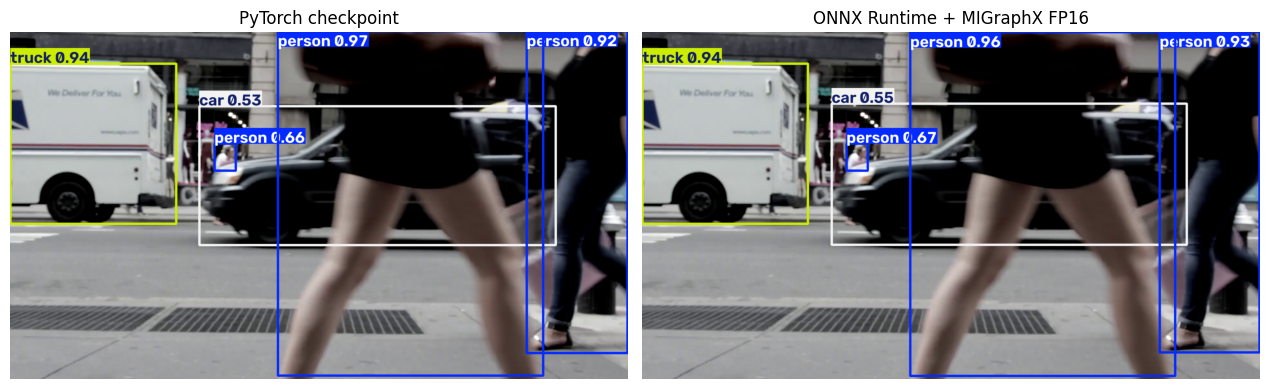

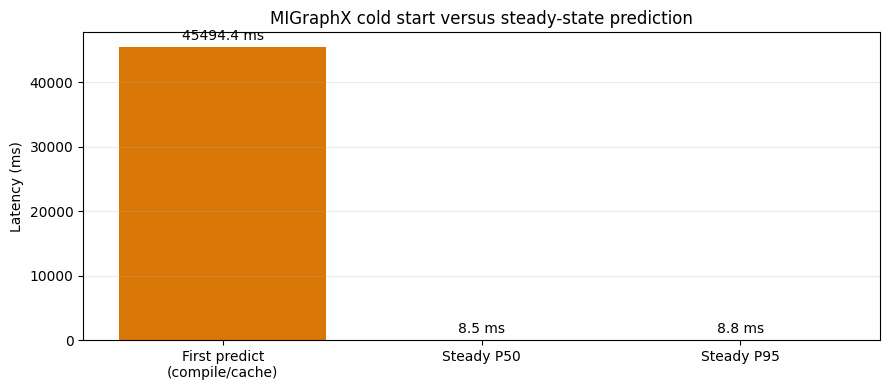

**Backend:** `MIGraphXExecutionProvider` / FP16 / I/O Binding. Steady P50 `8.47 ms` (118.0 calls/s); detected `5` objects.

In [3]:
import gc
import math
import statistics

import matplotlib.pyplot as plt
import torch

from migraphx_cache import prepare_cache

USE_FRESH_EXPORT = os.environ.get(
    "USE_FRESH_EXPORT", "1" if RUN_EXPORT else "0"
) == "1"
deployment_onnx = workshop_onnx if USE_FRESH_EXPORT else env.YOLO_ONNX
deployment_sha256 = hashlib.sha256(deployment_onnx.read_bytes()).hexdigest()
deployment_cache_root = (
    export_dir / "ort-migraphx-cache"
    if USE_FRESH_EXPORT
    else env.MIGRAPHX_CACHE
)
deployment_cache_root.mkdir(parents=True, exist_ok=True)
os.environ["ULTRALYTICS_MIGRAPHX_CACHE_ROOT"] = str(deployment_cache_root)
display(Markdown("Compiling/loading the MIGraphX program, then measuring steady-state prediction..."))

with capture_log(env.OUTPUT / "logs/onnx_migraphx.log", "ONNX/MIGraphX inference"):
    cache_dir, cache_identity = prepare_cache(
        deployment_onnx, deployment_cache_root, 0
    )
    construct_started = time.perf_counter()
    yolo = YOLO(str(deployment_onnx), task="detect")
    construct_ms = (time.perf_counter() - construct_started) * 1000

    torch.cuda.synchronize()
    first_started = time.perf_counter()
    result = yolo.predict(
        first_frame,
        device=0,
        half=True,
        imgsz=640,
        conf=0.5,
        iou=0.45,
        verbose=False,
    )[0]
    torch.cuda.synchronize()
    first_predict_ms = (time.perf_counter() - first_started) * 1000

    predict_samples_ms = []
    for _ in range(12):
        torch.cuda.synchronize()
        started = time.perf_counter()
        result = yolo.predict(
            first_frame,
            device=0,
            half=True,
            imgsz=640,
            conf=0.5,
            iou=0.45,
            verbose=False,
        )[0]
        torch.cuda.synchronize()
        predict_samples_ms.append((time.perf_counter() - started) * 1000)

backend = yolo.predictor.model.backend
assert backend.provider == "MIGraphXExecutionProvider"
assert backend.use_io_binding and backend.migraphx_fp16
ordered_predict = sorted(predict_samples_ms)
predict_p50_ms = statistics.median(predict_samples_ms)
predict_p95_ms = ordered_predict[math.ceil(len(ordered_predict) * 0.95) - 1]
result_plot = result.plot()
backend_timing = {
    "onnx": str(deployment_onnx),
    "fresh_export_selected": USE_FRESH_EXPORT,
    "provider": backend.provider,
    "io_binding": backend.use_io_binding,
    "migraphx_fp16": backend.migraphx_fp16,
    "cache": str(cache_dir),
    "construct_ms": round(construct_ms, 3),
    "first_predict_ms": round(first_predict_ms, 3),
    "steady_predict_p50_ms": round(predict_p50_ms, 3),
    "steady_predict_p95_ms": round(predict_p95_ms, 3),
    "single_call_rate_from_p50": round(1000 / predict_p50_ms, 1),
    "boxes": len(result.boxes),
}
show_bgr_grid(
    [pt_plot, result_plot],
    ["PyTorch checkpoint", "ONNX Runtime + MIGraphX FP16"],
    columns=2,
)
figure, axis = plt.subplots(figsize=(9, 4))
labels = ["First predict\n(compile/cache)", "Steady P50", "Steady P95"]
values = [first_predict_ms, predict_p50_ms, predict_p95_ms]
bars = axis.bar(labels, values, color=["#d97706", "#007c91", "#4f6d7a"])
axis.bar_label(bars, fmt="%.1f ms", padding=3)
axis.set_ylabel("Latency (ms)")
axis.set_title("MIGraphX cold start versus steady-state prediction")
axis.grid(axis="y", alpha=0.25)
figure.tight_layout()
plt.show()
display(Markdown(
    f"**Backend:** `{backend.provider}` / FP16 / I/O Binding. "
    f"Steady P50 `{predict_p50_ms:.2f} ms` ({1000 / predict_p50_ms:.1f} calls/s); "
    f"detected `{len(result.boxes)}` objects."
))
del result, yolo, backend
gc.collect()
torch.cuda.empty_cache()

## 4. Follow one frame across host and GPU

**Question:** where does a frame cross device boundaries?

```text
CPU round-trip: GPU decode -> full-frame D2H -> CPU overlay -> upload -> GPU encode
GPU direct:     GPU decode -> preprocess -> infer/NMS -> overlay/NV12 -> encode
```

**Evidence:** bytes, direction, synchronized P50/P95, and 25 FPS traffic.  
**Next:** remove repeated crossings instead of only tuning DMA.

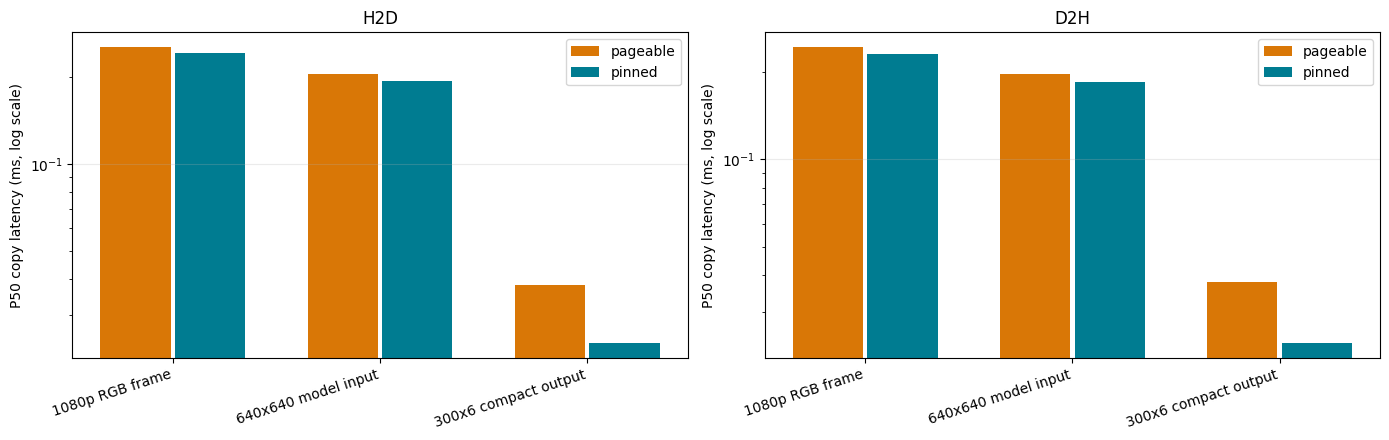

,path,MiB/frame,MiB/s at 25 FPS
0,one full-frame direction,5.933,148.315
1,D2H + upload round-trip,11.865,296.631
2,300x6 compact output,0.007,0.172


**Interpretation:** one DMA is small. The expensive design is a repeated full-frame round-trip that adds synchronization, CPU work, and another upload.

In [4]:
import pandas as pd


def percentile(values, fraction):
    ordered = sorted(values)
    return ordered[math.ceil(len(ordered) * fraction) - 1]


def measure_transfer(operation, payload_bytes, repeats=50, warmup=5):
    for _ in range(warmup):
        operation()
        torch.cuda.synchronize()
    samples_ms = []
    for _ in range(repeats):
        torch.cuda.synchronize()
        started = time.perf_counter()
        operation()
        torch.cuda.synchronize()
        samples_ms.append((time.perf_counter() - started) * 1000)
    p50_ms = statistics.median(samples_ms)
    return {
        "p50_ms": round(p50_ms, 4),
        "p95_ms": round(percentile(samples_ms, 0.95), 4),
        "effective_GBps": round(payload_bytes / (p50_ms * 1_000_000), 3),
    }


transfer_cases = [
    ("1080p RGB frame", (1080, 1920, 3), torch.uint8),
    ("640x640 model input", (1, 3, 640, 640), torch.float32),
    ("300x6 compact output", (1, 300, 6), torch.float32),
]
transfer_results = []
for payload_name, shape, dtype in transfer_cases:
    pageable_source = torch.empty(shape, dtype=dtype, device="cpu")
    pinned_source = torch.empty(shape, dtype=dtype, device="cpu", pin_memory=True)
    gpu_buffer = torch.empty(shape, dtype=dtype, device="cuda:0")
    pageable_destination = torch.empty(shape, dtype=dtype, device="cpu")
    pinned_destination = torch.empty(shape, dtype=dtype, device="cpu", pin_memory=True)
    payload_bytes = gpu_buffer.numel() * gpu_buffer.element_size()
    operations = [
        ("H2D", "pageable", lambda: gpu_buffer.copy_(pageable_source, non_blocking=False)),
        ("H2D", "pinned", lambda: gpu_buffer.copy_(pinned_source, non_blocking=True)),
        ("D2H", "pageable", lambda: pageable_destination.copy_(gpu_buffer, non_blocking=False)),
        ("D2H", "pinned", lambda: pinned_destination.copy_(gpu_buffer, non_blocking=True)),
    ]
    for direction, host_memory, operation in operations:
        transfer_results.append({
            "payload": payload_name,
            "direction": direction,
            "host_memory": host_memory,
            "payload_MiB": round(payload_bytes / 1024**2, 3),
            **measure_transfer(operation, payload_bytes),
        })

transfer_table = pd.DataFrame(transfer_results)
full_frame_mib = 1080 * 1920 * 3 / 1024**2
traffic = pd.DataFrame([
    {"path": "one full-frame direction", "MiB/frame": full_frame_mib, "MiB/s at 25 FPS": full_frame_mib * 25},
    {"path": "D2H + upload round-trip", "MiB/frame": full_frame_mib * 2, "MiB/s at 25 FPS": full_frame_mib * 50},
    {"path": "300x6 compact output", "MiB/frame": 300 * 6 * 4 / 1024**2, "MiB/s at 25 FPS": 300 * 6 * 4 / 1024**2 * 25},
])

figure, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for axis, direction in zip(axes, ("H2D", "D2H")):
    subset = transfer_table[transfer_table["direction"] == direction]
    for memory, color in (("pageable", "#d97706"), ("pinned", "#007c91")):
        values = subset[subset["host_memory"] == memory]
        offset = -0.18 if memory == "pageable" else 0.18
        axis.bar([index + offset for index in range(len(values))], values["p50_ms"], width=0.34, label=memory, color=color)
    axis.set_xticks(range(len(values)), values["payload"], rotation=18, ha="right")
    axis.set_yscale("log")
    axis.set_ylabel("P50 copy latency (ms, log scale)")
    axis.set_title(direction)
    axis.grid(axis="y", alpha=0.25)
    axis.legend()
figure.tight_layout()
plt.show()
display(traffic.round(3))
display(Markdown(
    "**Interpretation:** one DMA is small. The expensive design is a repeated "
    "full-frame round-trip that adds synchronization, CPU work, and another upload."
))

## 5. Keep the frame resident

**Question:** can decode, preprocess, inference, and NMS reuse GPU buffers?

**Evidence:** GPU tensors, detections, stable pointers, inference P50/P95.  
**Next:** prove the result did not change.

GPU-resident path: complete (full log: /workspace/output/step_by_step/logs/gpu_resident_path.log)
Warnings:
- [ERR]  {GetWidth}  Display width is 0.
- [ERR]  {GetHeight}  Display height is 0.


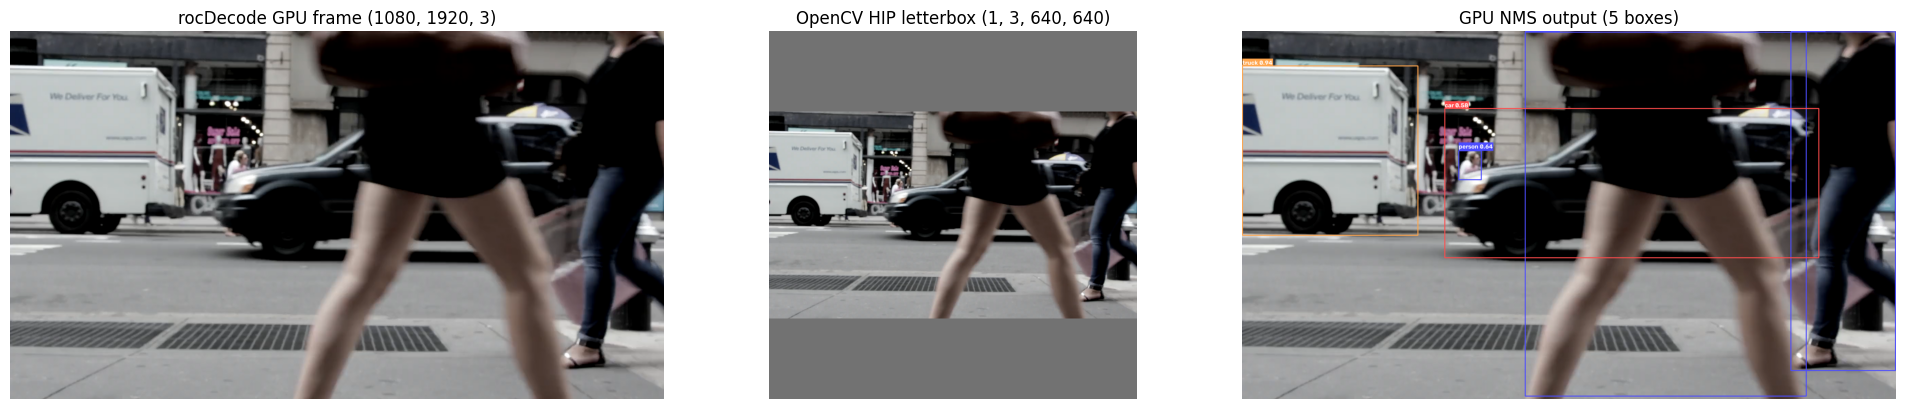

**Resident inference:** P50 `6.97 ms`, P95 `7.24 ms`; input/output pointers stayed stable. The two `.cpu()` copies above exist only to render this teaching figure.

In [5]:
import cv2
import config as pipeline_config

pipeline_config = importlib.reload(pipeline_config)
pipeline_config.YOLO_MODEL_PATH = str(deployment_onnx)

from detector import UltralyticsYOLODetector
from postprocess import draw_detections
from preprocess import GPUPreprocessor
from video_io import RocDecodeReader

with capture_log(env.OUTPUT / "logs/gpu_resident_path.log", "GPU-resident path"):
    reader = RocDecodeReader(str(env.SOURCE_VIDEO), device_id=0)
    processor = GPUPreprocessor((640, 640), device="cuda:0")
    detector = UltralyticsYOLODetector(model_path=str(deployment_onnx), device_id=0)
    try:
        ok, rgb_gpu = reader.read_gpu()
        assert ok and rgb_gpu.is_cuda
        blob_gpu, scale, pad_w, pad_h = processor.process(rgb_gpu)
        for _ in range(5):
            raw_gpu = detector.infer_gpu(blob_gpu)
        torch.cuda.synchronize()
        resident_samples_ms = []
        input_pointer = blob_gpu.data_ptr()
        output_pointer = raw_gpu.data_ptr()
        for _ in range(30):
            torch.cuda.synchronize()
            started = time.perf_counter()
            raw_gpu = detector.infer_gpu(blob_gpu)
            torch.cuda.synchronize()
            resident_samples_ms.append((time.perf_counter() - started) * 1000)
            assert blob_gpu.data_ptr() == input_pointer
            assert raw_gpu.data_ptr() == output_pointer
        detections = detector._parse_gpu(
            raw_gpu, scale, pad_w, pad_h, tuple(rgb_gpu.shape)
        )
        decoded_rgb = rgb_gpu.cpu().numpy()
        model_input_rgb = (
            blob_gpu[0].permute(1, 2, 0).clamp(0, 1).mul(255).byte().cpu().numpy()
        )
    finally:
        reader.release()

resident_inference = {
    "p50_ms": round(statistics.median(resident_samples_ms), 3),
    "p95_ms": round(percentile(resident_samples_ms, 0.95), 3),
    "input_pointer": input_pointer,
    "output_pointer": output_pointer,
}
decoded_bgr = cv2.cvtColor(decoded_rgb, cv2.COLOR_RGB2BGR)
model_input_bgr = cv2.cvtColor(model_input_rgb, cv2.COLOR_RGB2BGR)
production_plot = decoded_bgr.copy()
draw_detections(production_plot, detections, names=detector.names)
show_bgr_grid(
    [decoded_bgr, model_input_bgr, production_plot],
    [
        f"rocDecode GPU frame {tuple(rgb_gpu.shape)}",
        f"OpenCV HIP letterbox {tuple(blob_gpu.shape)}",
        f"GPU NMS output ({len(detections)} boxes)",
    ],
    columns=3,
)
display(Markdown(
    f"**Resident inference:** P50 `{resident_inference['p50_ms']:.2f} ms`, "
    f"P95 `{resident_inference['p95_ms']:.2f} ms`; input/output pointers stayed stable. "
    "The two `.cpu()` copies above exist only to render this teaching figure."
))
assert blob_gpu.device.type == "cuda" and raw_gpu.device.type == "cuda"

production_detections = list(detections)
production_names = detector.names
del detector, processor, raw_gpu, blob_gpu, rgb_gpu
gc.collect()
torch.cuda.empty_cache()

## 6. Gate optimization with correctness

**Question:** did the new data path change detections?

**Pass:** same box count/classes and class-matched IoU >= 0.90.  
**Next:** measure the resident stages.

Prediction parity: complete (full log: /workspace/output/step_by_step/logs/predict_production_parity.log)


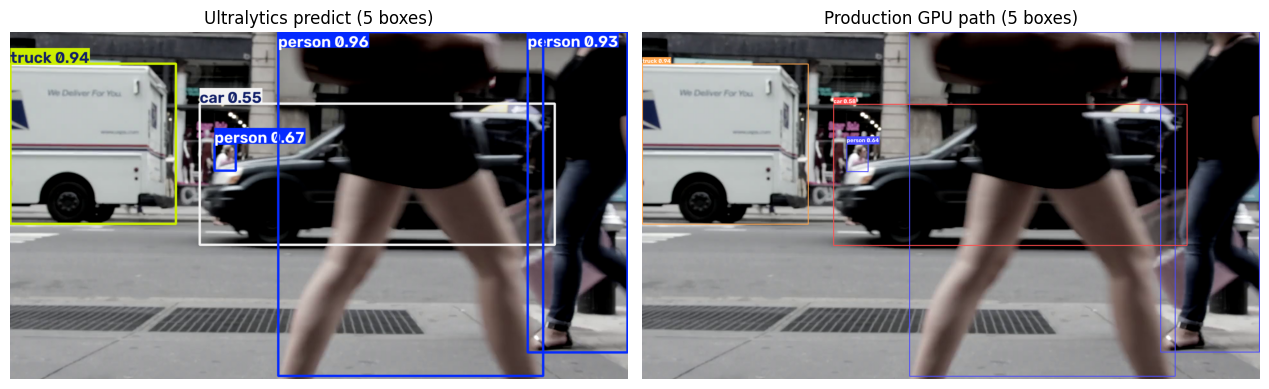

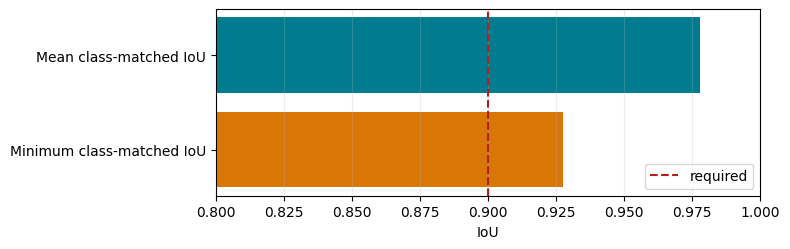

**Parity PASS:** minimum class-matched IoU `0.9275` >= `0.90`.

In [6]:
from tests.test_predict_production_parity import validate as validate_parity

with capture_log(env.OUTPUT / "logs/predict_production_parity.log", "Prediction parity"):
    parity = validate_parity(deployment_onnx, env.SOURCE_VIDEO, minimum_iou=0.90)

reference_plot = result_plot.copy()
production_parity_plot = first_frame.copy()
draw_detections(production_parity_plot, production_detections, names=production_names)
show_bgr_grid(
    [reference_plot, production_parity_plot],
    [
        f"Ultralytics predict ({parity['predict_boxes']} boxes)",
        f"Production GPU path ({parity['production_boxes']} boxes)",
    ],
    columns=2,
)
figure, axis = plt.subplots(figsize=(8, 2.6))
axis.barh(
    ["Minimum class-matched IoU", "Mean class-matched IoU"],
    [parity["minimum_class_matched_iou"], parity["mean_class_matched_iou"]],
    color=["#d97706", "#007c91"],
)
axis.axvline(parity["minimum_required_iou"], color="#b91c1c", linestyle="--", label="required")
axis.set_xlim(0.8, 1.0)
axis.set_xlabel("IoU")
axis.legend()
axis.grid(axis="x", alpha=0.25)
figure.tight_layout()
plt.show()
display(Markdown(
    f"**Parity PASS:** minimum class-matched IoU "
    f"`{parity['minimum_class_matched_iou']:.4f}` >= `{parity['minimum_required_iou']:.2f}`."
))
gc.collect()
torch.cuda.empty_cache()

## 7. Measure the resident stages

**Question:** after copies are removed, where is GPU time spent?

**Evidence:** rocDecode, HIP preprocess, MIGraphX, GPU NMS; mean and P95.  
**Next:** compare complete host round-trip and GPU-direct boundaries.

GPU stage benchmark: complete (full log: /workspace/output/step_by_step/logs/gpu_stage_benchmark.log)
Warnings:
- [ERR]  {GetWidth}  Display width is 0.
- [ERR]  {GetHeight}  Display height is 0.


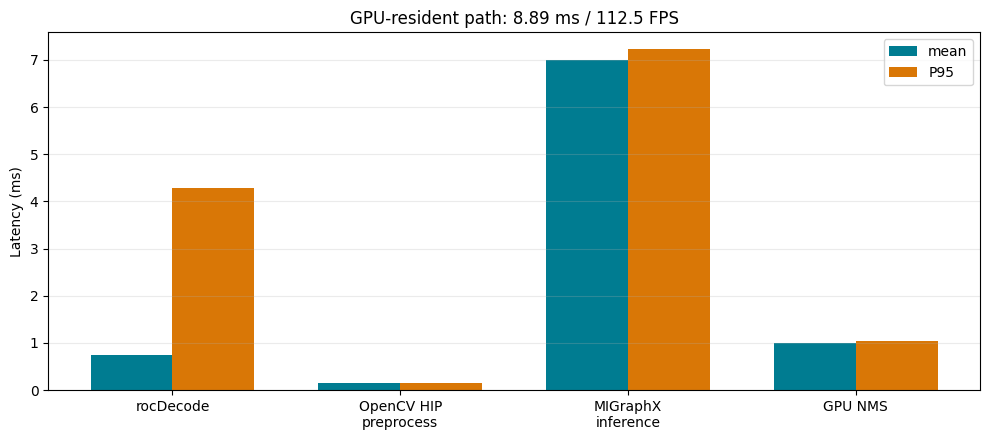

**Stable allocations:** `5` tracked pointers; all stayed unchanged across `120` measured frames.

In [7]:
from tests.benchmark_gpu_stages import benchmark

RUN_BENCHMARK = os.environ.get("RUN_BENCHMARK", "0") == "1"
benchmark_path = env.OUTPUT / f"benchmarks/gpu_stages_{deployment_sha256[:12]}.json"
if RUN_BENCHMARK or not benchmark_path.is_file():
    with capture_log(env.OUTPUT / "logs/gpu_stage_benchmark.log", "GPU stage benchmark"):
        gpu_benchmark = benchmark(
            env.SOURCE_VIDEO,
            frames=120,
            warmup=10,
            model_path=deployment_onnx,
        )
    benchmark_path.parent.mkdir(parents=True, exist_ok=True)
    benchmark_path.write_text(json.dumps(gpu_benchmark, indent=2) + "\n")
else:
    gpu_benchmark = json.loads(benchmark_path.read_text())
    print(f"GPU stage benchmark: reused {benchmark_path}")

stage_names = ["decode", "preprocess", "inference", "gpu_nms"]
stage_labels = ["rocDecode", "OpenCV HIP\npreprocess", "MIGraphX\ninference", "GPU NMS"]
means = [gpu_benchmark["stages"][name]["mean_ms"] for name in stage_names]
p95s = [gpu_benchmark["stages"][name]["p95_ms"] for name in stage_names]
figure, axis = plt.subplots(figsize=(10, 4.5))
positions = range(len(stage_names))
axis.bar([value - 0.18 for value in positions], means, width=0.36, label="mean", color="#007c91")
axis.bar([value + 0.18 for value in positions], p95s, width=0.36, label="P95", color="#d97706")
axis.set_xticks(list(positions), stage_labels)
axis.set_ylabel("Latency (ms)")
axis.set_title(f"GPU-resident path: {gpu_benchmark['gpu_path_mean_ms']:.2f} ms / {gpu_benchmark['gpu_path_fps']:.1f} FPS")
axis.grid(axis="y", alpha=0.25)
axis.legend()
figure.tight_layout()
plt.show()
display(Markdown(
    f"**Stable allocations:** `{len(gpu_benchmark['stable_pointers'])}` tracked pointers; "
    f"all stayed unchanged across `{gpu_benchmark['frames']}` measured frames."
))

## 8. Prove the boundary change end to end

**Question:** does deleting the host round-trip improve the real video path?

**Controlled A/B:** same video, model, 120 frames, rocDecode, and VA-API.

- CPU round-trip: full-frame D2H + CPU overlay + upload;
- GPU direct: resident overlay/NV12 + direct VA-API.

**Next:** keep vision stable, then add VLM as a separate low-frequency path.

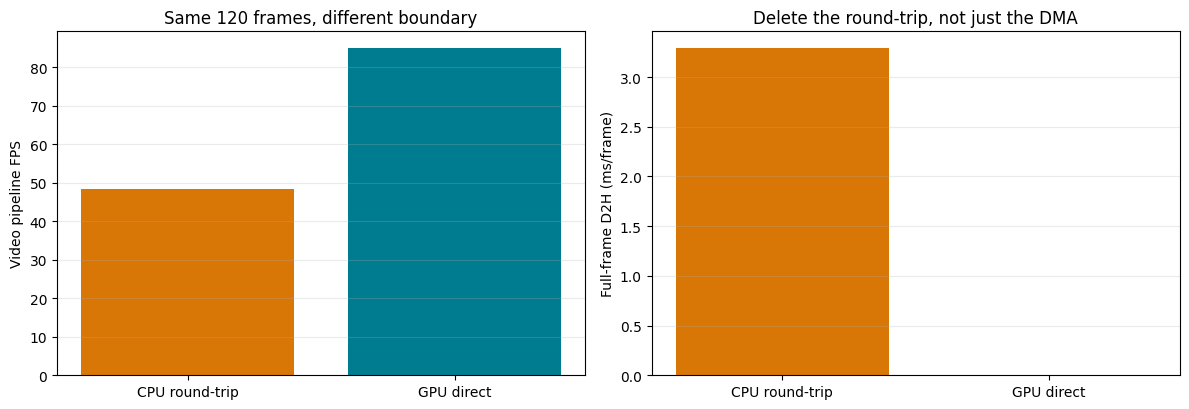

,path,fps,full_frame_d2h_ms,overlay_ms,encode_feed_ms
0,CPU round-trip,48.378,3.295,0.523,4.566
1,GPU direct,85.084,0.000,0.000,0.043


**Result:** GPU direct is `1.76x` the CPU round-trip throughput, with zero full-frame D2H.

In [8]:
import subprocess

from scripts.async_roi_workflow import run_experiment
from scripts import pipeline_workflow as workflow
workflow = importlib.reload(workflow)

AB_FRAMES = int(os.environ.get("STEP_V2_AB_FRAMES", "120"))
RUN_BOUNDARY_AB = os.environ.get("RUN_BOUNDARY_AB", "0") == "1"
ab_dir = env.OUTPUT / "boundary_ab"
ab_dir.mkdir(parents=True, exist_ok=True)

cpu_roundtrip = run_experiment(
    output_dir=ab_dir,
    mode="yolo-only",
    max_frames=AB_FRAMES,
    force=RUN_BOUNDARY_AB,
)

direct_video = ab_dir / "gpu_direct.mp4"
direct_metrics_path = ab_dir / "gpu_direct_metrics.json"
direct_log = ab_dir / "gpu_direct.log"
direct_command = workflow.pipeline_command(
    source=env.SOURCE_VIDEO,
    output=direct_video,
    max_frames=AB_FRAMES,
)
direct_command.extend(["--metrics-json", str(direct_metrics_path)])
if RUN_BOUNDARY_AB or not all(path.is_file() for path in (direct_video, direct_metrics_path, direct_log)):
    process = subprocess.run(
        direct_command,
        cwd=env.ROOT,
        env=os.environ.copy(),
        capture_output=True,
        text=True,
    )
    direct_log.write_text(process.stdout + process.stderr, encoding="utf-8")
    if process.returncode:
        raise RuntimeError(f"GPU-direct run failed; see {direct_log}")
else:
    print(f"GPU-direct boundary run: reused {direct_metrics_path}")

direct_metrics = json.loads(direct_metrics_path.read_text())
direct_video_info = workflow.video_info(direct_video)
for key in ("container_samples", "packets", "decoded_frames"):
    assert direct_video_info[key] == AB_FRAMES, (key, direct_video_info[key])
assert cpu_roundtrip["metrics"]["frames"] == direct_metrics["frames"] == AB_FRAMES
assert cpu_roundtrip["metrics"]["frame_d2h_mean_ms"] > 0
assert direct_metrics["frame_d2h_mean_ms"] == 0

boundary_ab = pd.DataFrame([
    {
        "path": "CPU round-trip",
        "fps": cpu_roundtrip["metrics"]["fps"],
        "full_frame_d2h_ms": cpu_roundtrip["metrics"]["frame_d2h_mean_ms"],
        "overlay_ms": cpu_roundtrip["metrics"]["overlay_mean_ms"],
        "encode_feed_ms": cpu_roundtrip["metrics"]["encode_feed_mean_ms"],
    },
    {
        "path": "GPU direct",
        "fps": direct_metrics["fps"],
        "full_frame_d2h_ms": direct_metrics["frame_d2h_mean_ms"],
        "overlay_ms": direct_metrics["overlay_mean_ms"],
        "encode_feed_ms": direct_metrics["encode_feed_mean_ms"],
    },
])
figure, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].bar(boundary_ab["path"], boundary_ab["fps"], color=["#d97706", "#007c91"])
axes[0].set_ylabel("Video pipeline FPS")
axes[0].set_title("Same 120 frames, different boundary")
axes[0].grid(axis="y", alpha=0.25)
axes[1].bar(boundary_ab["path"], boundary_ab["full_frame_d2h_ms"], color=["#d97706", "#007c91"])
axes[1].set_ylabel("Full-frame D2H (ms/frame)")
axes[1].set_title("Delete the round-trip, not just the DMA")
axes[1].grid(axis="y", alpha=0.25)
figure.tight_layout()
plt.show()
display(boundary_ab.round(3))
display(Markdown(
    f"**Result:** GPU direct is `{direct_metrics['fps'] / cpu_roundtrip['metrics']['fps']:.2f}x` "
    "the CPU round-trip throughput, with zero full-frame D2H."
))

## 9. Keep VLM off the per-frame critical path

**Question:** what does the semantic stage receive and return?

**Evidence:** three-frame storyboard, one caption, one separately timed request.  
**Rule:** do not fold VLM latency into detector FPS.

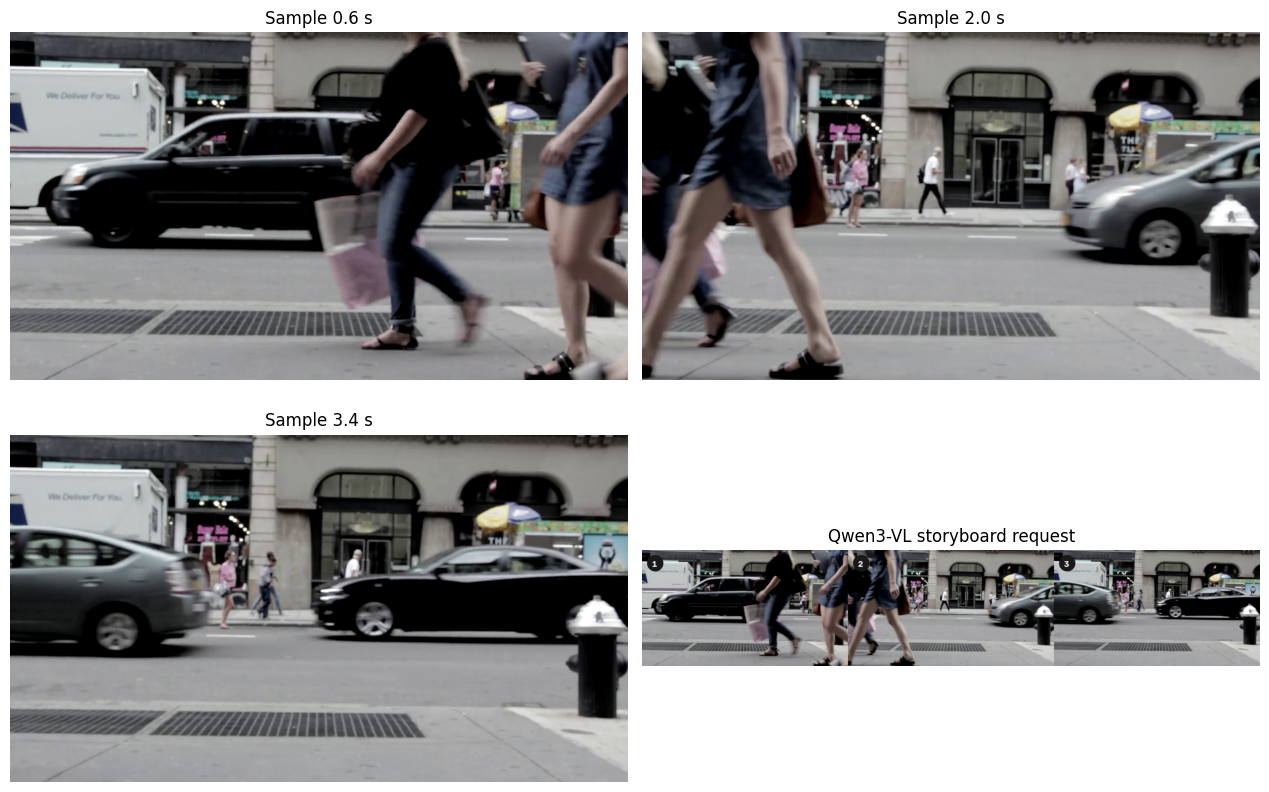

**Qwen3-VL output** (0.381 s, verified timeline):  Pedestrians cross street as cars pass by in urban setting.

In [9]:
from scripts import pipeline_workflow as workflow
workflow = importlib.reload(workflow)

RUN_VLM_LIVE = os.environ.get("RUN_VLM_LIVE", "0") == "1"
if not workflow.TIMELINE.is_file():
    with capture_log(env.OUTPUT / "logs/production_workflow.log", "Production workflow"):
        workflow_result = workflow.run_workflow(force=False)

timeline = json.loads(workflow.TIMELINE.read_text())
first_segment = timeline["segments"][0]
storyboard_path = workflow.RUN_DIR / first_segment["storyboard"]
storyboard = cv2.imread(str(storyboard_path))
assert storyboard is not None
sample_frames = [frame_at(env.SOURCE_VIDEO, seconds) for seconds in first_segment["sample_times"]]
show_bgr_grid(
    [*sample_frames, storyboard],
    [
        *[f"Sample {seconds:.1f} s" for seconds in first_segment["sample_times"]],
        "Qwen3-VL storyboard request",
    ],
    columns=2,
)

vlm_record = {
    "backend": timeline["backend"],
    "model": timeline["model"],
    "interval_seconds": timeline["interval_seconds"],
    "input": str(storyboard_path),
    "sample_times": first_segment["sample_times"],
    "output": first_segment["caption"],
    "latency_seconds": first_segment["latency_seconds"],
    "source": "verified timeline",
}
if RUN_VLM_LIVE:
    from vlm_client import LlamaCppVLMClient

    with capture_log(env.OUTPUT / "logs/vlm_live_request.log", "Live VLM request"):
        client = LlamaCppVLMClient(base_url=env.LLAMACPP_BASE_URL)
        assert client.health_check()
        started = time.perf_counter()
        live_output = client.describe_roi(storyboard, timeline["prompt"])
    vlm_record.update({
        "output": live_output,
        "latency_seconds": round(time.perf_counter() - started, 3),
        "source": "live request",
    })
display(Markdown(
    f"**Qwen3-VL output** ({vlm_record['latency_seconds']:.3f} s, {vlm_record['source']}):  "
    f"{vlm_record['output']}"
))

## 10. Validate production artifacts

**Question:** did the optimized design survive the complete workflow?

**Evidence:** YOLO and YOLO+VLM videos, 393/393 frames, zero full-frame D2H on the direct path.

Production video workflow: reused verified artifacts


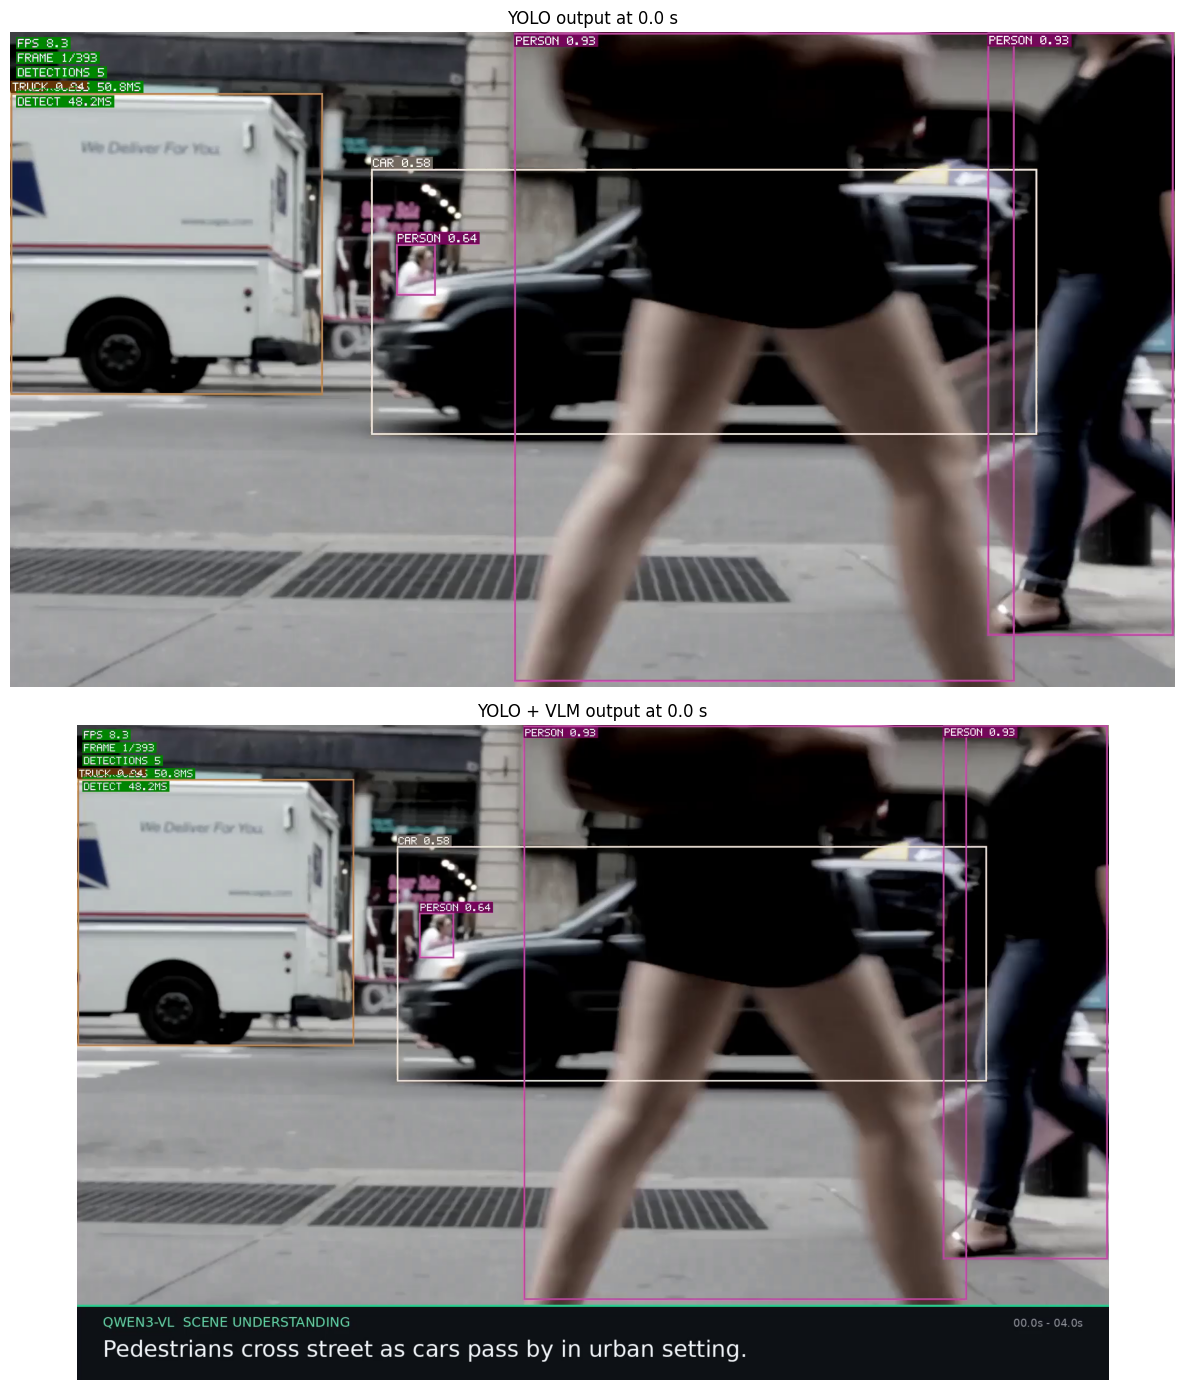

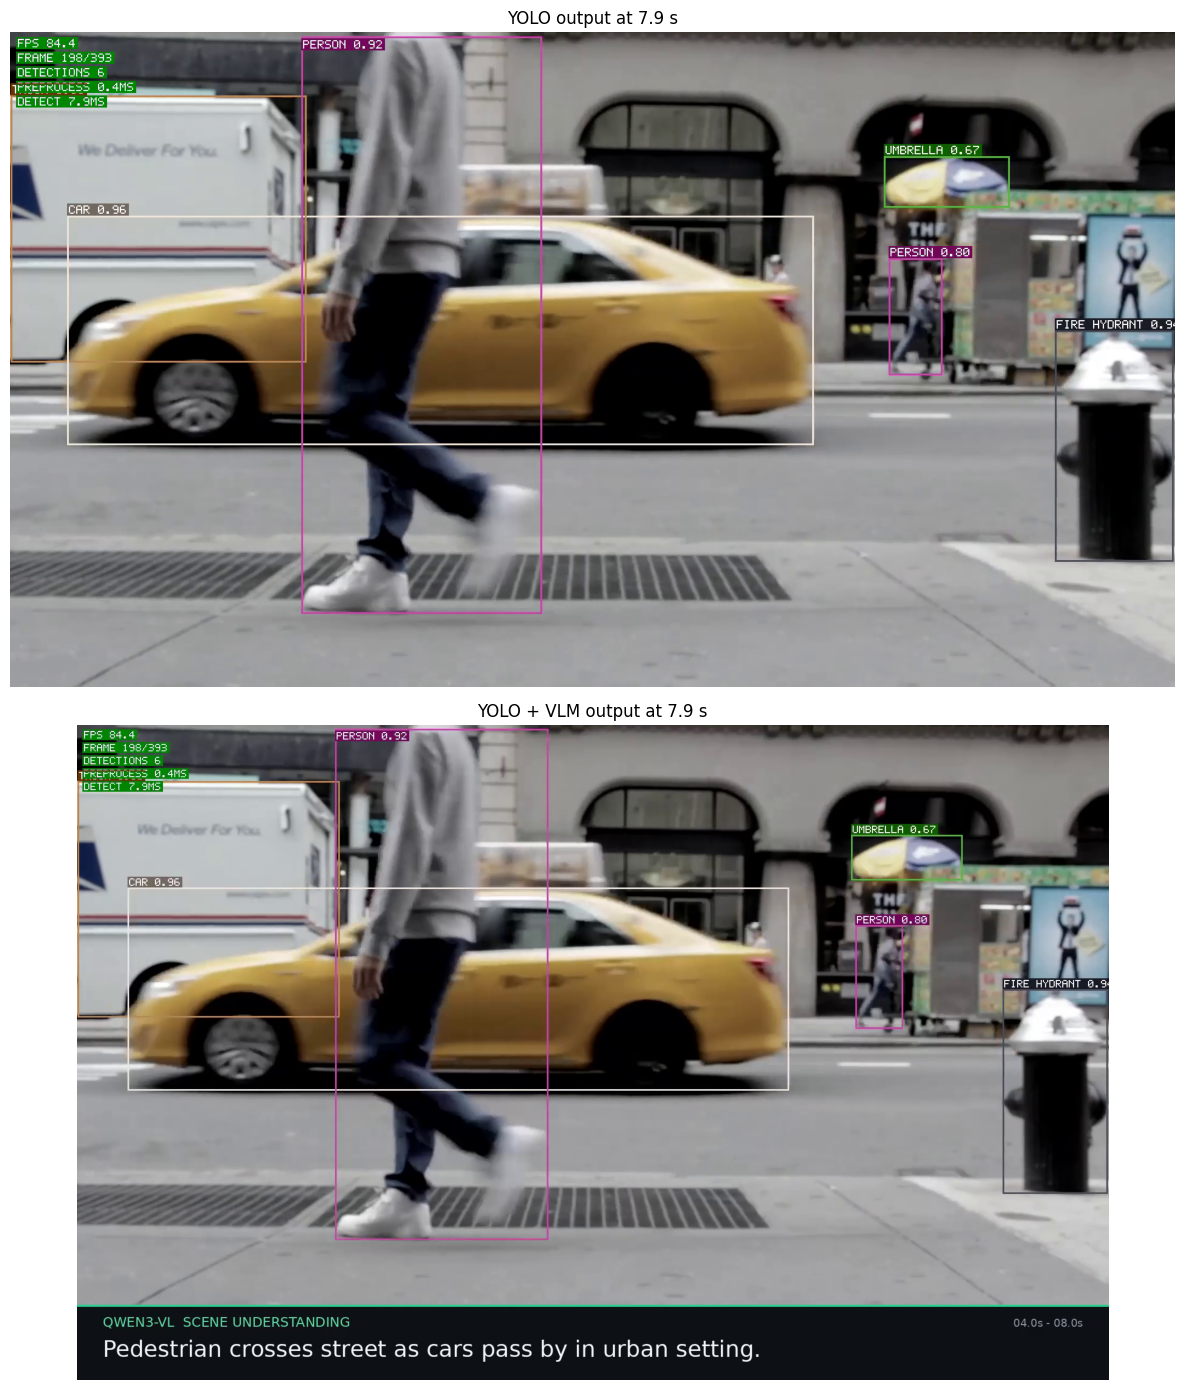

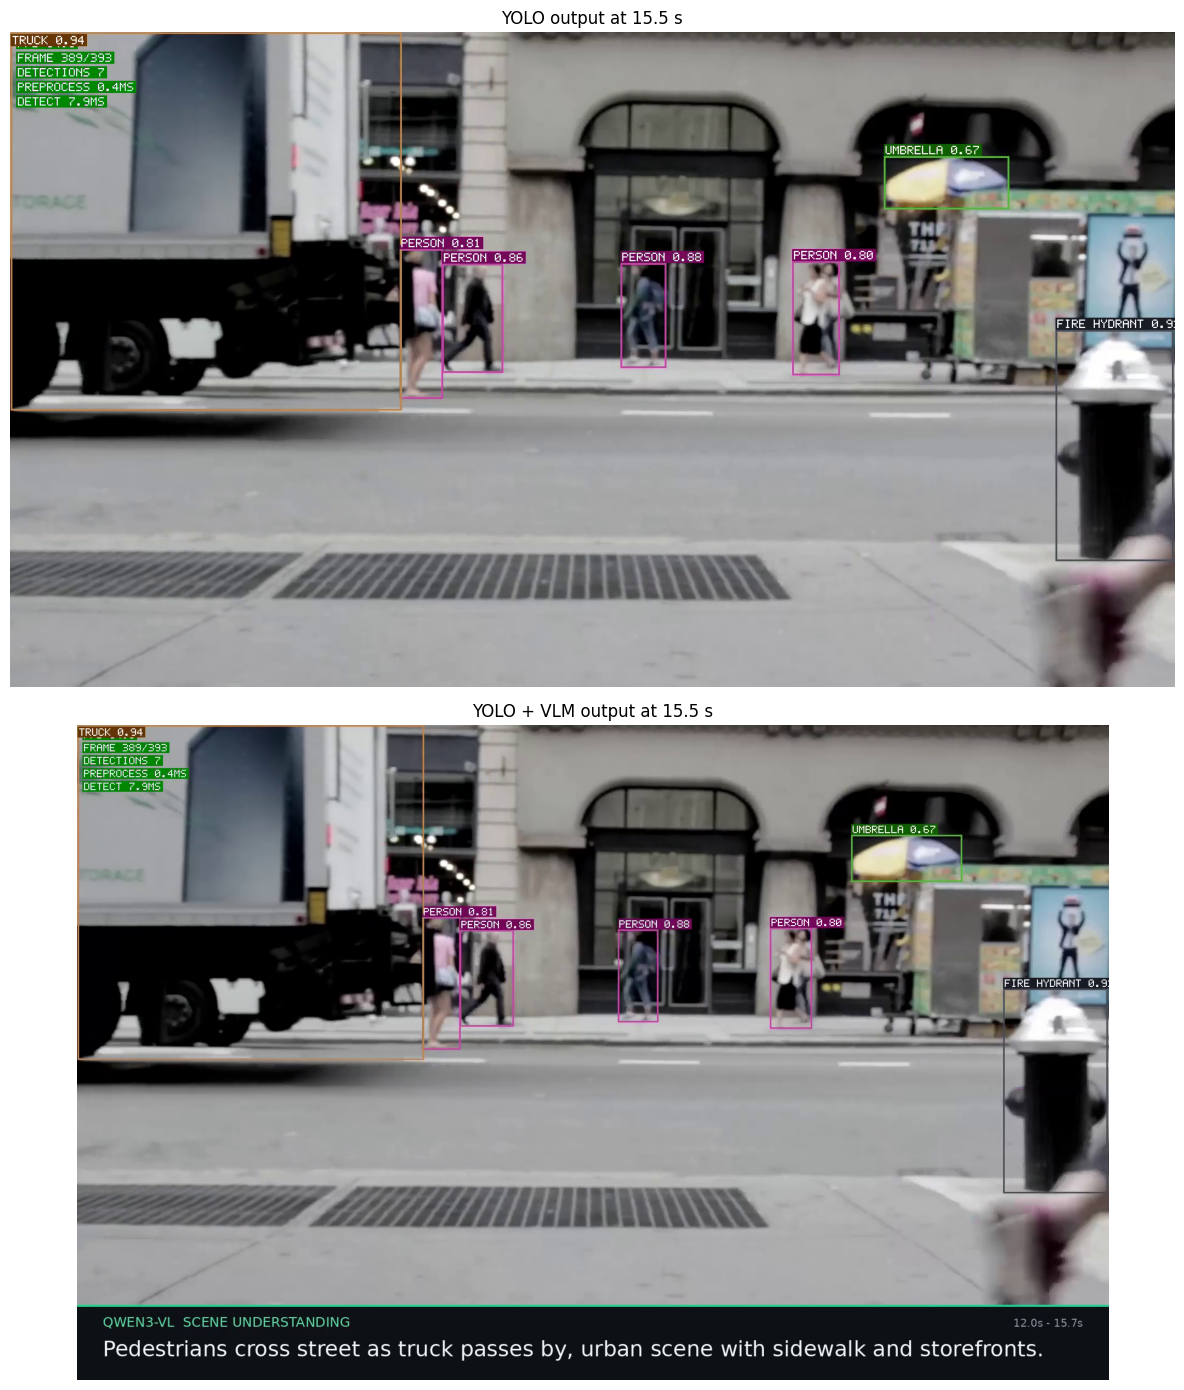

**Production result:** `93.7 FPS`; full-frame D2H `0.00 ms`; submitted/encoded frames `393/393`.

In [10]:
from scripts import pipeline_workflow as workflow
workflow = importlib.reload(workflow)

RUN_PIPELINE = os.environ.get("RUN_PIPELINE", "0") == "1"
os.environ["ULTRALYTICS_MIGRAPHX_CACHE_ROOT"] = str(env.MIGRAPHX_CACHE)
outputs_ready = all(path.is_file() for path in workflow.required_outputs())
identity_ready, _ = workflow.manifest_matches_current()
if RUN_PIPELINE or not (outputs_ready and identity_ready):
    with capture_log(env.OUTPUT / "logs/production_workflow.log", "Production video workflow"):
        workflow_result = workflow.run_workflow(force=RUN_PIPELINE)
else:
    workflow_result = workflow.validate_outputs()
    print("Production video workflow: reused verified artifacts")
manifest = json.loads(workflow.MANIFEST.read_text())
performance = manifest["pipeline"]["performance"]

yolo_times = [0.0, source_info["duration_seconds"] / 2, max(0.0, source_info["duration_seconds"] - 0.2)]
yolo_frames = [frame_at(workflow.YOLO_VIDEO, seconds) for seconds in yolo_times]
final_frames = [frame_at(workflow.FINAL_VIDEO, seconds) for seconds in yolo_times]
for seconds, yolo_frame, final_frame in zip(yolo_times, yolo_frames, final_frames):
    show_bgr_grid(
        [yolo_frame, final_frame],
        [
            f"YOLO output at {seconds:.1f} s",
            f"YOLO + VLM output at {seconds:.1f} s",
        ],
        columns=1,
        size=(16, 14),
    )
show_video(workflow.YOLO_VIDEO, "YOLO26 GPU-resident detection video")
show_video(workflow.FINAL_VIDEO, "Final YOLO26 + Qwen3-VL video")
display(Markdown(
    f"**Production result:** `{performance['fps']:.1f} FPS`; full-frame D2H "
    f"`{performance['frame_d2h_ms']:.2f} ms`; submitted/encoded frames "
    f"`{performance['direct_encode_submitted_frames']}/{performance['direct_encode_encoded_frames']}`."
))

## 11. Final boundary audit

```text
H.264 -> rocDecode -> HIP preprocess -> MIGraphX -> GPU NMS
      -> compact detections D2H
      -> HIP overlay/RGB-to-NV12 -> direct VA-API
```

- No full-frame D2H in the YOLO direct path.
- Compact detection metadata still crosses to host.
- Notebook images, JPEG/HTTP VLM input, and subtitle rendering are explicit host boundaries.

**Method:** locate, measure, remove, verify parity, remeasure end to end.